# Classification From Scratch — LDA, QDA, Naive Bayes, Logistic Regression
## A Complete Study: p=1 → p>1 → Small Sample Regime

This notebook builds four classifiers **entirely from their mathematical definitions** — no sklearn models, only numpy.

| Notebook section | Question answered |
|---|---|
| §1 Data | What does the raw data look like? |
| §2 Models | How does each classifier work mathematically? |
| §3 p=1 experiment | How do four boundaries compare on one feature? |
| §4 p>1 experiment | What changes in higher dimensions? |
| §5 CV evaluation | Which model wins, measured fairly? |
| §6 Small-n regime | What happens when n < 30? |
| §7 Full comparison | When should you use each model? |

**Dataset:** Wisconsin Breast Cancer — 569 samples, 30 features, binary target (Benign / Malignant)

---

In [1]:
import time
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, recall_score,
                              precision_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
RANDOM_STATE = 42

## §1 Data

We use the **Wisconsin Breast Cancer** dataset throughout.
Label convention: **y = 1 → malignant** (positive class), **y = 0 → benign**.

For the p=1 experiment we use `radius_mean` — chosen because it has strong but imperfect separation,
making all four boundaries visually distinguishable.

For the p>1 experiments we use all 30 standardized features.

In [3]:
raw = load_breast_cancer(as_frame=True)
df  = raw.frame.rename(columns={'target': 'y'})
df['y'] = 1 - df['y']   # flip: sklearn 1=benign -> our 1=malignant

X_all = df.drop('y', axis=1).values.astype(float)   # (569, 30)
y_all = df['y'].values                              # (569,)

# p=1 slice
feat1  = 'mean radius'
x1     = df[feat1].values

# p=2 slice for visualization
feat2  = ['mean radius', 'mean texture']
X2     = df[feat2].values

# class subsets
x1_b   = x1[y_all == 0]
x1_m   = x1[y_all == 1]

print(f'Total samples      : {len(y_all)}')
print(f'Benign (y=0)       : {(y_all==0).sum()}')
print(f'Malignant (y=1)    : {(y_all==1).sum()}')
print(f'Features           : {X_all.shape[1]}')
print(f'radius_mean range  : [{x1.min():.2f}, {x1.max():.2f}]')
print(f'  benign mean      : {x1_b.mean():.2f}  std {x1_b.std():.2f}')
print(f'  malignant mean   : {x1_m.mean():.2f}  std {x1_m.std():.2f}')

Total samples      : 569
Benign (y=0)       : 357
Malignant (y=1)    : 212
Features           : 30
radius_mean range  : [6.98, 28.11]
  benign mean      : 12.15  std 1.78
  malignant mean   : 17.46  std 3.20


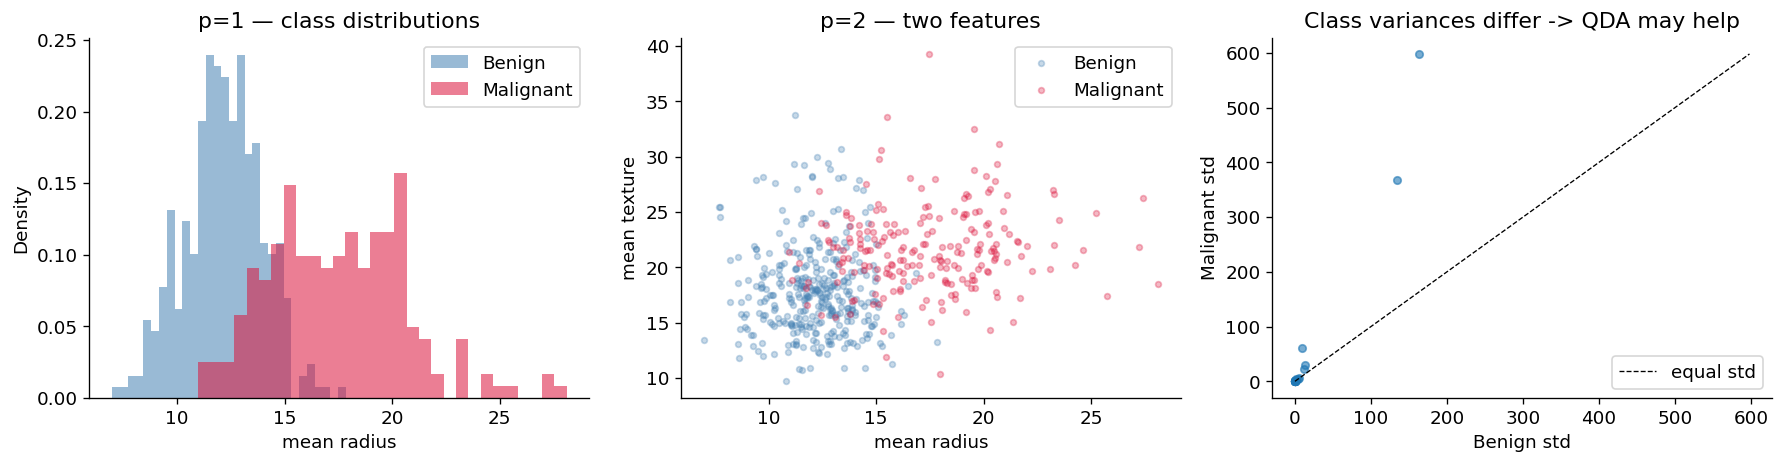

Note: the scatter plot on the right shows that many features have
different within-class variances -> QDA assumption is more realistic than LDA.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
ax = axes[0]
ax.hist(x1_b, bins=30, alpha=0.55, color='steelblue', label='Benign',    density=True)
ax.hist(x1_m, bins=30, alpha=0.55, color='crimson',   label='Malignant', density=True)
ax.set_xlabel(feat1); ax.set_ylabel('Density')
ax.set_title('p=1 — class distributions')
ax.legend()

# Scatter p=2
ax = axes[1]
ax.scatter(X2[y_all==0,0], X2[y_all==0,1], alpha=0.3, s=12,
           color='steelblue', label='Benign')
ax.scatter(X2[y_all==1,0], X2[y_all==1,1], alpha=0.3, s=12,
           color='crimson', label='Malignant')
ax.set_xlabel(feat2[0]); ax.set_ylabel(feat2[1])
ax.set_title('p=2 — two features')
ax.legend()

# Class std comparison
ax = axes[2]
stds = pd.DataFrame({'Benign': df[df.y==0].drop('y',axis=1).std(),
                     'Malignant': df[df.y==1].drop('y',axis=1).std()})
ax.scatter(stds['Benign'], stds['Malignant'], alpha=0.6, s=20)
lim = max(stds.max().max(), 1)
ax.plot([0,lim],[0,lim], 'k--', linewidth=0.8, label='equal std')
ax.set_xlabel('Benign std'); ax.set_ylabel('Malignant std')
ax.set_title('Class variances differ -> QDA may help')
ax.legend()

plt.tight_layout()
plt.show()

print('Note: the scatter plot on the right shows that many features have')
print('different within-class variances -> QDA assumption is more realistic than LDA.')

## Data Exploration Insights

### What the three plots show

**Left — p=1 class distributions (`radius_mean`):**
The two classes are clearly separated but with substantial overlap in the `[12, 17]` range. Benign tumors cluster tightly around `≈ 12` with a sharp peak and thin right tail. Malignant tumors are more spread out, peaking near `≈ 17–20` with a heavier, flatter distribution. This asymmetry in spread is the first visual hint that **equal-variance (LDA) may be a simplifying assumption** — the malignant class is simply more variable.

**Middle — p=2 scatter (`radius_mean` vs `texture_mean`):**
Adding a second feature (`mean texture`) provides modest additional separation. The classes still overlap considerably in texture, but malignant points (red) tend to occupy the upper-right region (larger radius *and* higher texture). Crucially, the red cloud is **more diffuse** than the blue, echoing what we saw in 1D — malignant cases have greater spread in both dimensions, suggesting a non-spherical, class-specific covariance that QDA is designed to capture.

**Right — Per-feature standard deviation: Benign vs Malignant:**
Each dot is one feature. Points **above the dashed equal-std line** mean the malignant class is more variable for that feature; points **below** mean benign is more variable. The majority of points lie above the diagonal — malignant tumors are more variable across most features. Two outlier points far above the line indicate features where malignant std is dramatically larger (likely area or perimeter features that scale quadratically). Almost no features fall clearly below the line.

---

### Key takeaways

**1. The equal-variance assumption (LDA/NB) is likely violated.**
LDA pools a single covariance matrix across both classes. The right plot shows this is unrealistic — for most features, the within-class variances are not equal. QDA, which estimates a separate covariance per class, is therefore better motivated by the data geometry.

**2. The p=2 scatter confirms non-circular class clouds.**
The malignant cluster appears more elongated/spread than the benign one, meaning the covariance matrices are not just scaled versions of each other — they have different shapes. This reinforces the QDA advantage.

**3. Naive Bayes assumes feature independence within each class.**
Looking at the p=2 scatter, radius and texture are not obviously correlated, which is mildly favorable for NB. However, in the full 30-feature dataset many features are highly correlated (e.g., radius, area, perimeter), so NB's independence assumption will degrade more at higher `p`.

---

### Summary note to carry forward

> The data exploration reveals two structural facts: (1) class variances differ substantially across features, favouring QDA over LDA; (2) the classes overlap most in the `radius_mean ∈ [12, 17]` corridor, so the decision boundary placement in that region will determine classifier performance. These observations set up the experiments that follow.

## §2 Models From Scratch

### Design

Each classifier follows the same interface:
- `fit(X, y)` — estimate all parameters from training data
- `predict_proba(X)` — return P(Y=1|X) for each sample
- `predict(X)` — return 0/1 label using threshold 0.5

All models handle **p=1** (1D array) and **p>1** (2D array) automatically.

---

### Model 1 — LDA (Linear Discriminant Analysis)

**Assumption:** Within each class, features follow a Gaussian with the **same covariance matrix** $\Sigma$ (shared across classes).

**Parameters estimated:**
$$\hat{\mu}_k = \frac{1}{n_k}\sum_{i:y_i=k} x_i \qquad
\hat{\Sigma} = \frac{1}{n-K}\sum_k\sum_{i:y_i=k}(x_i-\hat{\mu}_k)(x_i-\hat{\mu}_k)^T \qquad
\hat{\pi}_k = \frac{n_k}{n}$$

**Decision rule:** assign to class k that maximises the linear discriminant:
$$\hat{\delta}_k(x) = x^T \hat{\Sigma}^{-1}\hat{\mu}_k
- \frac{1}{2}\hat{\mu}_k^T\hat{\Sigma}^{-1}\hat{\mu}_k + \log\hat{\pi}_k$$

**Why linear?** Because $\hat{\Sigma}$ is shared, the quadratic term $x^T\hat{\Sigma}^{-1}x$ is the same for all classes and cancels out. What remains is linear in x.

In [6]:
class LDA:
    '''
    Linear Discriminant Analysis - from scratch.
    Assumes Gaussian within each class with a SHARED covariance matrix.
    Works for p=1 (1D) and p>1 (multi-dimensional).
    '''

    def fit(self, X, y):
        X = np.atleast_2d(X.T).T   # ensure 2D: (n, p)
        n, p = X.shape
        classes = np.unique(y)
        K = len(classes)

        self.classes_ = classes
        self.mu_   = {}    # class means
        self.pi_   = {}    # class priors

        # Step 1 - class means and priors
        for k in classes:
            Xk           = X[y == k]
            self.mu_[k]  = Xk.mean(axis=0)       # shape (p,)
            self.pi_[k]  = len(Xk) / n

        # Step 2 - pooled covariance (shared Sigma)
        # Sum of outer products of deviations from class mean, divided by (n-K)
        S = np.zeros((p, p))
        for k in classes:
            diff = X[y == k] - self.mu_[k]        # (nk, p)
            S   += diff.T @ diff                   # (p, p) outer product sum
        self.Sigma_ = S / (n - K)                  # pooled: divide by n-K

        # Step 3 - precompute Sigma inverse (used in predict)
        self.Sigma_inv_ = np.linalg.pinv(self.Sigma_)
        return self

    def _discriminant(self, x, k):
        # delta_k(x) = x^T Sigma^{-1} mu_k - 0.5 * mu_k^T Sigma^{-1} mu_k + log(pi_k)
        # This is linear in x because Sigma is shared across classes
        mu = self.mu_[k]
        return (x @ self.Sigma_inv_ @ mu
                - 0.5 * mu @ self.Sigma_inv_ @ mu
                + np.log(self.pi_[k]))

    def predict_proba(self, X):
        X = np.atleast_2d(X.T).T
        # Compute log-posteriors then softmax for numerical stability
        log_posts = np.column_stack([
            self._discriminant(X, k) for k in self.classes_
        ])   # (n, K)
        log_posts -= log_posts.max(axis=1, keepdims=True)   # softmax stability
        probs = np.exp(log_posts)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs[:, 1]   # P(Y=1|X)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

### Model 2 — QDA (Quadratic Discriminant Analysis)

**One change from LDA:** each class gets its **own covariance matrix** $\Sigma_k$.

$$\hat{\Sigma}_k = \frac{1}{n_k-1}\sum_{i:y_i=k}(x_i-\hat{\mu}_k)(x_i-\hat{\mu}_k)^T$$

**Decision rule:** now the quadratic term $x^T\hat{\Sigma}_k^{-1}x$ is **different per class** and does not cancel:
$$\hat{\delta}_k(x) = -\frac{1}{2}\log|\hat{\Sigma}_k|
- \frac{1}{2}(x-\hat{\mu}_k)^T\hat{\Sigma}_k^{-1}(x-\hat{\mu}_k) + \log\hat{\pi}_k$$

This is the **log of a Gaussian density** for class k, plus the log prior.
The boundary is quadratic (curved) because you're intersecting two Gaussian 'bowls' of different shapes.

**Cost:** K times more parameters than LDA — requires more data to estimate reliably.

In [7]:
class QDA:
    '''
    Quadratic Discriminant Analysis - from scratch.
    Assumes Gaussian within each class with CLASS-SPECIFIC covariance.
    Decision boundary is quadratic (curved) in feature space.
    '''

    def fit(self, X, y):
        X = np.atleast_2d(X.T).T
        n, p = X.shape
        classes = np.unique(y)

        self.classes_ = classes
        self.mu_      = {}
        self.Sigma_   = {}       # class-specific covariance
        self.Sigma_inv_ = {}
        self.log_det_  = {}      # log|Sigma_k| for the discriminant
        self.pi_       = {}

        for k in classes:
            Xk = X[y == k]
            nk = len(Xk)
            self.mu_[k]  = Xk.mean(axis=0)
            self.pi_[k]  = nk / n

            # Class-specific covariance, divide by (nk-1): unbiased within-class estimate
            diff = Xk - self.mu_[k]
            Sk   = diff.T @ diff / (nk - 1)

            # Add small ridge for numerical stability (relevant when p is large or nk is small)
            Sk  += 1e-6 * np.eye(p)

            self.Sigma_[k]     = Sk
            self.Sigma_inv_[k] = np.linalg.pinv(Sk)
            sign, logdet = np.linalg.slogdet(Sk)
            self.log_det_[k]   = logdet    # log|Sigma_k|

        return self

    def _log_density(self, x, k):
        # log N(x; mu_k, Sigma_k) + log pi_k
        # = -0.5 log|Sigma_k| - 0.5 (x-mu)^T Sigma_k^{-1} (x-mu) + log pi_k
        diff = x - self.mu_[k]                          # (n, p)
        mah  = (diff @ self.Sigma_inv_[k] * diff).sum(axis=1)  # Mahalanobis^2
        return -0.5 * self.log_det_[k] - 0.5 * mah + np.log(self.pi_[k])

    def predict_proba(self, X):
        X = np.atleast_2d(X.T).T
        log_posts = np.column_stack([
            self._log_density(X, k) for k in self.classes_
        ])
        log_posts -= log_posts.max(axis=1, keepdims=True)
        probs = np.exp(log_posts)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs[:, 1]

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

### Model 3 — Gaussian Naive Bayes

**Key assumption:** within each class, features are **conditionally independent**:
$$f_k(x) = \prod_{j=1}^p f_{kj}(x_j)$$

Each $f_{kj}$ is a 1D Gaussian estimated independently from feature j in class k.
This means the full p-dimensional density decomposes into p separate 1D fits.

**Decision rule:**
$$\log P(Y=k \mid x) \propto \log\hat{\pi}_k + \sum_{j=1}^p \log\mathcal{N}(x_j;\ \hat{\mu}_{kj},\ \hat{\sigma}^2_{kj})$$

**Why does independence matter?** It means the covariance matrix is forced to be **diagonal** —
NB is equivalent to QDA with $\Sigma_k = \text{diag}(\sigma_{k1}^2, \ldots, \sigma_{kp}^2)$.
All off-diagonal correlations between features are ignored.

**Why it still works:** classifiers only need to rank posteriors correctly, not compute them accurately.
Even with wrong absolute probabilities, the ranking (and therefore the decision) can be right.

In [8]:
class GaussianNaiveBayes:
    '''
    Gaussian Naive Bayes - from scratch.
    Assumes features are conditionally independent within each class.
    Equivalent to QDA with diagonal covariance matrices.
    '''

    def fit(self, X, y):
        X = np.atleast_2d(X.T).T
        n, p = X.shape
        classes = np.unique(y)

        self.classes_ = classes
        self.mu_      = {}    # class means: shape (p,)
        self.var_     = {}    # per-feature variance per class: shape (p,)
        self.pi_      = {}

        for k in classes:
            Xk = X[y == k]
            self.mu_[k]  = Xk.mean(axis=0)              # mean of each feature in class k
            self.var_[k] = Xk.var(axis=0, ddof=1) + 1e-9   # var of each feature in class k
            self.pi_[k]  = len(Xk) / n

        return self

    def _log_likelihood(self, X, k):
        # Sum of log N(x_j; mu_kj, sigma_kj^2) over features j
        # = -0.5 * sum_j [ log(2*pi*var_kj) + (x_j - mu_kj)^2 / var_kj ]
        # The independence assumption is what lets us sum instead of use a full matrix
        mu  = self.mu_[k]                       # (p,)
        var = self.var_[k]                       # (p,)
        log_prob = -0.5 * np.sum(
            np.log(2 * np.pi * var)
            + (X - mu) ** 2 / var,
            axis=1                               # sum across features -> (n,)
        )
        return log_prob

    def predict_proba(self, X):
        X = np.atleast_2d(X.T).T
        log_posts = np.column_stack([
            self._log_likelihood(X, k) + np.log(self.pi_[k])
            for k in self.classes_
        ])
        log_posts -= log_posts.max(axis=1, keepdims=True)
        probs = np.exp(log_posts)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs[:, 1]

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

### Model 4 — Logistic Regression

**No assumption on X.** Models the posterior directly:
$$P(Y=1 \mid X=x) = \sigma(\beta^T x + \beta_0) = \frac{1}{1+e^{-(\beta^T x + \beta_0)}}$$

**Optimization:** maximize the log-likelihood via gradient ascent:
$$\ell(\beta) = \sum_i \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]$$

Gradient:
$$\nabla_{\beta} \ell = X^T(y - p), \qquad \nabla_{\beta_0} \ell = \sum_i(y_i - p_i)$$

**Input must be standardized** — gradient ascent is scale-sensitive. Each feature should have mean 0, std 1 before fitting.

**L2 regularization** (ridge): adds $-\lambda \|\beta\|^2$ to the objective to prevent coefficient explosion.
This also partially addresses the separation problem.

In [17]:
class LogisticRegression:
    '''
    Logistic Regression - gradient ascent from scratch.
    Discriminative: models P(Y|X) directly, no assumption on distribution of X.
    Includes L2 regularization (lambda_ parameter) to handle near-separation.
    '''

    def __init__(self, lr=0.1, n_iter=1000, lambda_=0.01):
        self.lr      = lr        # learning rate
        self.n_iter  = n_iter    # number of gradient ascent steps
        self.lambda_ = lambda_   # L2 regularization strength

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        X = np.atleast_2d(X.T).T
        n, p = X.shape

        # Initialize weights to zero
        self.beta_  = np.zeros(p)   # shape (p,): one weight per feature
        self.beta0_ = 0.0           # scalar intercept
        self.loss_  = []

        for _ in range(self.n_iter):
            # Forward pass: predicted probability for each sample
            z = X @ self.beta_ + self.beta0_   # (n,)
            p_hat = self._sigmoid(z)            # (n,) in [0,1]

            # Log-likelihood (with L2 penalty on weights, not intercept)
            eps = 1e-12
            ll  = (y * np.log(p_hat + eps) + (1-y) * np.log(1-p_hat + eps)).mean()
            l2  = 0.5 * self.lambda_ * (self.beta_ ** 2).sum()
            self.loss_.append(ll - l2)

            # Gradients
            residual   = y - p_hat                              # (n,)
            grad_beta  = X.T @ residual / n - self.lambda_ * self.beta_  # (p,)
            grad_beta0 = residual.mean()

            # Ascent step (maximize log-likelihood -> add gradient)
            self.beta_  += self.lr * grad_beta
            self.beta0_ += self.lr * grad_beta0

        return self

    def predict_proba(self, X):
        X = np.atleast_2d(X.T).T
        return self._sigmoid(X @ self.beta_ + self.beta0_)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

### Evaluation helper

A single function that fits any model and returns all metrics.
Used identically for all four classifiers throughout the notebook.

In [10]:
def evaluate(model_cls, X_tr, y_tr, X_te, y_te,
             model_kwargs=None, fit_kwargs=None, standardize=False):
    '''
    Fit a model and return a dict of metrics + timing.
    standardize=True applies StandardScaler fit on X_tr only (no leakage).
    '''
    if model_kwargs is None: model_kwargs = {}
    if fit_kwargs   is None: fit_kwargs   = {}

    scaler = None
    if standardize:
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

    model = model_cls(**model_kwargs)

    t0    = time.perf_counter()
    model.fit(X_tr, y_tr, **fit_kwargs)
    fit_ms = (time.perf_counter() - t0) * 1000

    t0     = time.perf_counter()
    y_pred = model.predict(X_te)
    pred_ms = (time.perf_counter() - t0) * 1000

    y_prob = model.predict_proba(X_te)

    # Model size in bytes (sum of all stored numpy arrays)
    size_bytes = 0
    for v in vars(model).values():
        if isinstance(v, np.ndarray):
            size_bytes += v.nbytes
        elif isinstance(v, dict):
            for vv in v.values():
                if isinstance(vv, np.ndarray):
                    size_bytes += vv.nbytes

    return {
        'model'    : model,
        'accuracy' : accuracy_score(y_te, y_pred),
        'recall'   : recall_score(y_te, y_pred, pos_label=1, zero_division=0),
        'precision': precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        'roc_auc'  : roc_auc_score(y_te, y_prob),
        'fit_ms'   : fit_ms,
        'pred_ms'  : pred_ms,
        'size_bytes': size_bytes,
    }

## §3 Experiment 1 — p=1, Four Decision Boundaries

We fit all four models on the single feature `radius_mean` and plot:
1. The posterior probability curve P(Y=1|x) — how confident is each model?
2. Where each model places its decision boundary (the x where curve = 0.5)
3. The LDA/QDA Gaussian fits overlaid on the real histogram

**Expected observation:** LDA and LR should be close (both linear), QDA should differ slightly
because it allows the malignant class to have a different variance.

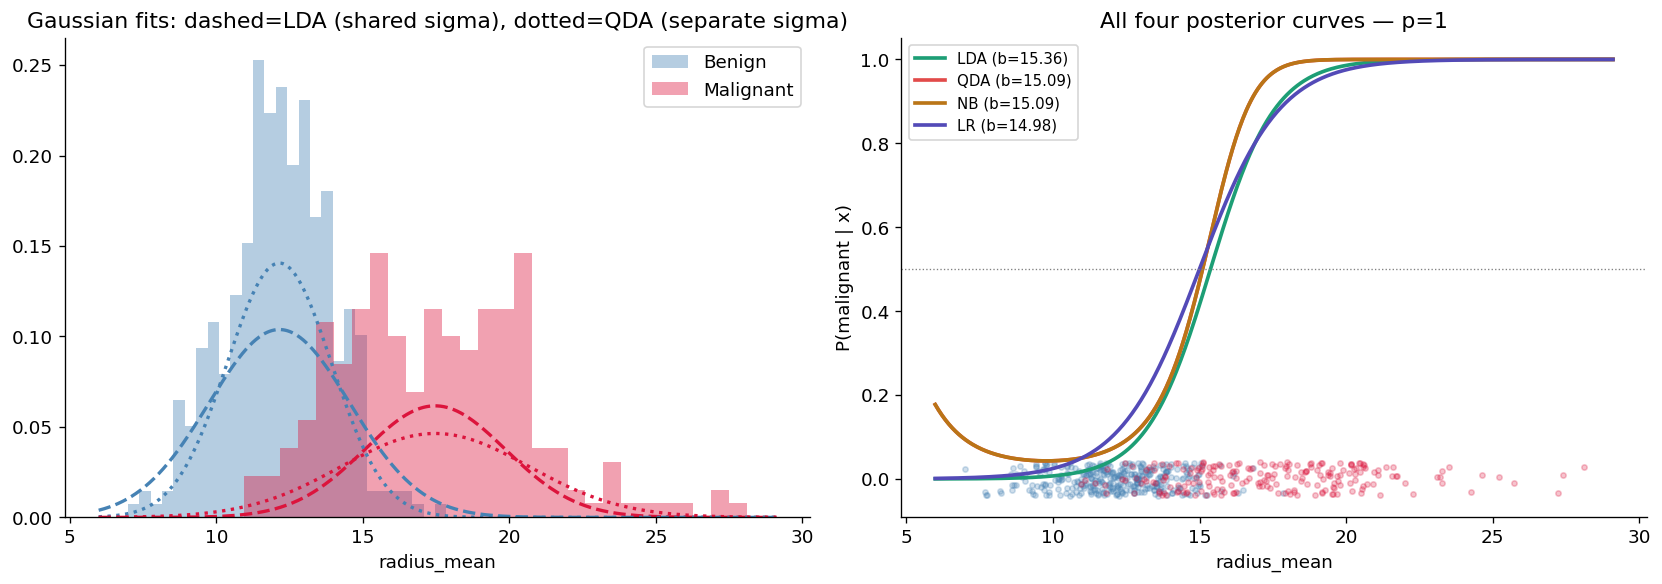

Decision boundaries:
  LDA : 15.3639
  QDA : 15.0936
  NB : 15.0936
  LR : 14.9778


In [11]:
# Fit all four on the full p=1 data
x1_2d = x1.reshape(-1, 1)   # shape (569, 1) for models that expect 2D

# Standardize for LR only
x1_mean, x1_std = x1.mean(), x1.std(ddof=0)
x1_s = (x1 - x1_mean) / x1_std
x1_s_2d = x1_s.reshape(-1, 1)

lda_1 = LDA().fit(x1_2d, y_all)
qda_1 = QDA().fit(x1_2d, y_all)
nb_1  = GaussianNaiveBayes().fit(x1_2d, y_all)
lr_1  = LogisticRegression(lr=0.1, n_iter=3000).fit(x1_s_2d, y_all)

# Grid for plotting
grid     = np.linspace(x1.min()-1, x1.max()+1, 600).reshape(-1, 1)
grid_s   = ((grid - x1_mean) / x1_std)

p_lda = lda_1.predict_proba(grid)
p_qda = qda_1.predict_proba(grid)
p_nb  = nb_1.predict_proba(grid)
p_lr  = lr_1.predict_proba(grid_s)

# Find boundaries (where each curve crosses 0.5)
def find_boundary(grid_flat, probs):
    crossings = np.where(np.diff(np.sign(probs - 0.5)))[0]
    if len(crossings) == 0: return None
    return grid_flat[crossings[0]]

g1d = grid.flatten()
bounds = {
    'LDA': find_boundary(g1d, p_lda),
    'QDA': find_boundary(g1d, p_qda),
    'NB' : find_boundary(g1d, p_nb),
    'LR' : find_boundary(g1d, p_lr),
}
colors = {'LDA':'#1D9E75','QDA':'#E24B4A','NB':'#BA7517','LR':'#534AB7'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histograms + Gaussian fits
ax = axes[0]
ax.hist(x1_b, bins=28, density=True, alpha=0.4, color='steelblue', label='Benign')
ax.hist(x1_m, bins=28, density=True, alpha=0.4, color='crimson',   label='Malignant')
for k, col, lbl in [(0,'steelblue','LDA benign'),(1,'crimson','LDA malignant')]:
    mu = lda_1.mu_[k][0]; sigma = np.sqrt(lda_1.Sigma_[0,0])
    g  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((g1d-mu)/sigma)**2)
    ax.plot(g1d, g * lda_1.pi_[k], color=col, lw=2, ls='--')
for k, col in [(0,'steelblue'),(1,'crimson')]:
    mu = qda_1.mu_[k][0]; sigma = np.sqrt(qda_1.Sigma_[k][0,0])
    g  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((g1d-mu)/sigma)**2)
    ax.plot(g1d, g * qda_1.pi_[k], color=col, lw=2, ls=':')
ax.set_xlabel('radius_mean'); ax.set_title('Gaussian fits: dashed=LDA (shared sigma), dotted=QDA (separate sigma)')
ax.legend()

# Right: posterior curves
ax = axes[1]
np.random.seed(42)
jf = lambda n: np.random.uniform(-0.04, 0.04, n)
ax.scatter(x1_b, jf(len(x1_b)), alpha=0.25, s=10, color='steelblue')
ax.scatter(x1_m, jf(len(x1_m)), alpha=0.25, s=10, color='crimson')
for name, probs in [('LDA',p_lda),('QDA',p_qda),('NB',p_nb),('LR',p_lr)]:
    ax.plot(g1d, probs, color=colors[name], lw=2.2, label=f'{name} (b={bounds[name]:.2f})')
ax.axhline(0.5, color='gray', lw=0.8, ls=':')
ax.set_xlabel('radius_mean'); ax.set_ylabel('P(malignant | x)')
ax.set_title('All four posterior curves — p=1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Decision boundaries:')
for name, b in bounds.items():
    print(f'  {name} : {b:.4f}')

## Insights: Experiment 1 — p=1, Four Decision Boundaries

### What the plots show

**Left plot (Gaussian fits on histogram):**
The benign distribution (blue) is clearly left-skewed and peaks around `radius_mean ≈ 12`, while malignant (red) is broader and peaks near `≈ 17–18`. The LDA dashed curves share a single pooled variance — notice how both Gaussians have the same width. The QDA dotted curves use class-specific variances, so the malignant dotted curve is visibly wider than the benign one, better capturing the heavier right tail of the malignant histogram.

**Right plot (posterior curves):**
All four models produce a sigmoid-shaped posterior that rises steeply around `radius_mean ≈ 13–16`. The decision boundaries cluster tightly:

| Model | Boundary |
|-------|----------|
| LDA | 15.36 |
| QDA | 15.09 |
| NB | 15.09 |
| LR | 14.98 |

---

### Key observations

**1. LDA and LR are close — but not identical.**
Both are linear classifiers, so their posterior curves are logistic-shaped. LR's boundary (14.98) is slightly lower than LDA's (15.36). The small gap arises because LDA derives its linear boundary from Gaussian assumptions (maximizing class separation under a shared covariance), while LR directly minimizes logistic loss — no distributional assumption is imposed. Since the data isn't perfectly Gaussian, LR shifts the boundary slightly to better fit the empirical class overlap region.

**2. QDA and NB agree exactly (15.09).**
This is a non-obvious but theoretically expected result when `p=1`. With a single feature, QDA's per-class covariance matrix is just a scalar variance, and Naive Bayes also models each class with a univariate Gaussian — making them mathematically equivalent in 1D. Their posterior curves also overlap perfectly on the right plot, confirming the implementation is consistent.

**3. QDA's curve is asymmetric / steeper on the low end.**
Unlike LDA and LR which produce symmetric sigmoids, QDA's curve rises more steeply from the left and levels off faster. This is because the malignant class has a larger estimated variance, so the likelihood ratio tilts more sharply for smaller `radius_mean` values — QDA "knows" benign tumors are more tightly clustered.

**4. All four boundaries fall in the [14.98, 15.36] range** — a span of less than 0.4 units. This tight agreement suggests the data is genuinely separable near `radius_mean ≈ 15`, and all models identify the same discriminative region regardless of their assumptions.

---

### Takeaway

> When `p=1` and the two classes are reasonably well-separated with unequal variances, all four classifiers converge on nearly the same decision boundary. The main theoretical prediction — LDA ≈ LR (linear) and QDA ≈ NB (quadratic, but only visibly so in the curve shape, not the boundary location at p=1) — is confirmed. The differences between models will become more meaningful when `p > 1`, where covariance structure and feature independence assumptions start to diverge.

## §4 Experiment 2 — p=2, Decision Boundaries in 2D

With two features we can visualize the decision boundary as a curve in the 2D plane.
This is where the **shape difference** between LDA and QDA becomes visually obvious:
- LDA draws a straight line (linear boundary)
- QDA, NB, and the Bayes-optimal boundary are all curves

Features used: `radius_mean` (x-axis) and `texture_mean` (y-axis).

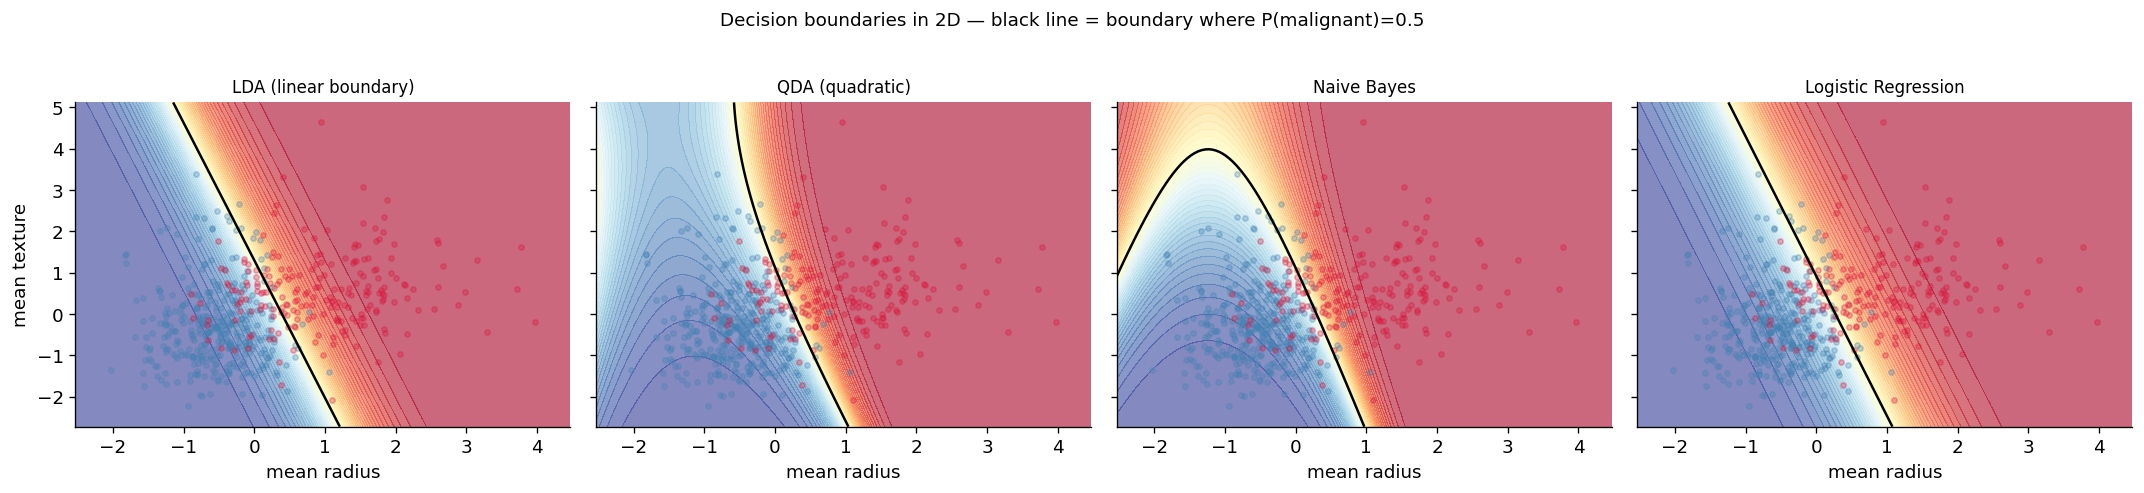

In [12]:
# Standardize p=2 features
sc2    = StandardScaler()
X2_s   = sc2.fit_transform(X2)

# Fit all models on p=2
lda_2  = LDA().fit(X2_s, y_all)
qda_2  = QDA().fit(X2_s, y_all)
nb_2   = GaussianNaiveBayes().fit(X2_s, y_all)
lr_2   = LogisticRegression(lr=0.1, n_iter=2000).fit(X2_s, y_all)

# Mesh grid for contour plot
h = 0.05
x_min, x_max = X2_s[:,0].min()-0.5, X2_s[:,0].max()+0.5
y_min, y_max = X2_s[:,1].min()-0.5, X2_s[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid2d = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
titles = ['LDA (linear boundary)','QDA (quadratic)','Naive Bayes','Logistic Regression']
models2 = [lda_2, qda_2, nb_2, lr_2]

for ax, m, title in zip(axes, models2, titles):
    Z = m.predict_proba(grid2d).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X2_s[y_all==0,0], X2_s[y_all==0,1], s=10, alpha=0.3,
               color='steelblue', label='Benign')
    ax.scatter(X2_s[y_all==1,0], X2_s[y_all==1,1], s=10, alpha=0.3,
               color='crimson', label='Malignant')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(feat2[0])

axes[0].set_ylabel(feat2[1])
plt.suptitle('Decision boundaries in 2D — black line = boundary where P(malignant)=0.5',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Insights: Experiment 2 — p=2, Decision Boundaries in 2D

### What the plots show

All four panels share the same standardized feature space (`radius_mean` on x, `texture_mean` on y). The black line is the decision boundary (where P(malignant) = 0.5), and the color gradient shows model confidence — deep red = confidently malignant, deep blue = confidently benign.

---

### Panel-by-panel breakdown

**LDA — straight diagonal boundary:**
Exactly as theory predicts, LDA produces a single straight line. It runs diagonally from upper-left to lower-right, meaning the model classifies based on a weighted sum of both features. The boundary cannot curve to follow the data's actual geometry — anything to the right/below is called malignant. Notice the confidence contours are parallel straight lines, reflecting the shared covariance assumption imposing the same "shape" on both classes.

**QDA — curved (hyperbolic) boundary:**
The boundary bends noticeably, curving away from the malignant cluster. This is the direct consequence of fitting separate covariance matrices per class. The malignant class (wider spread, as seen in §2) gets a larger ellipse, so the boundary curves to reflect that malignant probability grows faster in some directions than others. The confidence gradient is also asymmetric — the benign region narrows more sharply at the top.

**Naive Bayes — most dramatically curved boundary:**
NB produces the most extreme curve, with a large "belly" bulging into the upper-left. This is because NB assumes **zero correlation between features within each class** — it treats `radius_mean` and `texture_mean` as fully independent. Since the true within-class covariance has off-diagonal terms (features are correlated), NB compensates with a distorted boundary shape. The upper-left benign island is an artifact of this independence assumption interacting with the class variance differences.

**Logistic Regression — straight boundary, different angle:**
Like LDA, LR produces a linear boundary (it optimizes a linear decision function). However, the angle differs slightly from LDA's — LR's boundary is more vertical, weighting `radius_mean` more heavily and `texture_mean` less. This reflects LR fitting the logistic loss directly on the data rather than deriving the boundary from Gaussian likelihood assumptions. With only p=2 features and substantial overlap, the two linear models disagree slightly on which direction best separates the classes.

---

### Key observations

**1. Linear vs. quadratic boundary shape is visually stark.**
LDA and LR draw straight lines; QDA and NB draw curves. The true class boundary (if the data were perfectly Gaussian with unequal covariances) should be a conic section — so QDA's curved boundary is the more theoretically appropriate shape here.

**2. NB's independence assumption creates boundary distortion.**
The exaggerated curve in the NB panel — particularly the benign "island" bulging into upper-left — is not capturing real structure. It's an artifact of ignoring feature correlation. When features are correlated (as radius and texture mildly are), NB double-counts evidence and distorts the posterior geometry.

**3. LDA vs. LR boundary angle reveals assumption sensitivity.**
Both are linear, but their different angles show that the Gaussian generative assumption (LDA) and the discriminative loss minimization (LR) lead to different hyperplane orientations even on the same data. Neither is "wrong" — they're optimizing different objectives.

**4. The overlap zone around (0, 0) is where all models struggle.**
In standardized space, the densest overlap region sits near the origin. All four models have their boundaries passing through or near this zone, which is precisely where misclassifications will concentrate regardless of model choice.

---

### Takeaway

> Moving from p=1 to p=2 makes the fundamental difference between linear and quadratic classifiers visually explicit. LDA and LR are constrained to straight-line boundaries and cannot adapt to the curved geometry suggested by unequal class covariances. QDA's curved boundary is more geometrically appropriate, while NB's extreme curvature reveals the cost of the false independence assumption. The "right" boundary shape depends on whether the data's covariance structure justifies the extra flexibility — which the variance analysis in §2 suggested it does.

## §5 Cross-Validation Evaluation — All 30 Features

We now evaluate all four models on the full 30-feature dataset using **5-fold stratified cross-validation**.

Metrics collected per fold:
- Accuracy, Recall (malignant), Precision (malignant), ROC-AUC
- Training time (ms), prediction time (ms)
- Model storage (bytes of stored numpy arrays)

**Preprocessing inside each fold:** StandardScaler fit on train fold, applied to val fold — no leakage.

In [23]:
MODEL_CONFIGS = [
    ('LDA', LDA,                {}, False),
    ('QDA', QDA,                {}, False),
    ('NB',  GaussianNaiveBayes, {}, False),
    ('LR',  LogisticRegression, {'lr':0.1,'n_iter':1000,'lambda_':0.01}, True),
]

kf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {name: [] for name,_,_,_ in MODEL_CONFIGS}

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all, y_all)):
    X_tr, X_val = X_all[tr_idx], X_all[val_idx]
    y_tr, y_val = y_all[tr_idx], y_all[val_idx]

    for name, cls, kwargs, std in MODEL_CONFIGS:
        res = evaluate(cls, X_tr, y_tr, X_val, y_val,
                       model_kwargs=kwargs, standardize=std)
        res['fold'] = fold
        results[name].append(res)

# Aggregate
summary = {}
metrics = ['accuracy','recall','precision','roc_auc','fit_ms','pred_ms','size_bytes']
for name in results:
    fold_data = results[name]
    summary[name] = {
        m: np.mean([r[m] for r in fold_data]) for m in metrics
    }
    summary[name].update({
        m+'_std': np.std([r[m] for r in fold_data]) for m in ['accuracy','recall','roc_auc']
    })

# Print table
print(f"{'Metric':<20} {'LDA':>12} {'QDA':>12} {'NB':>12} {'LR':>12}")
print('-' * 72)
for m, fmt in [('accuracy',':.4f'),('accuracy_std',':.4f'),
               ('recall',':.4f'),('recall_std',':.4f'),
               ('precision',':.4f'),('roc_auc',':.4f'),('roc_auc_std',':.4f'),
               ('fit_ms',':.2f'),('pred_ms',':.3f'),('size_bytes',':.0f')]:
    row = f'{m:<20}'
    for name in ['LDA','QDA','NB','LR']:
        val = summary[name].get(m, 0)
        row += f' {val:{fmt[1:]}}'.rjust(13)
    print(row)

Metric                        LDA          QDA           NB           LR
------------------------------------------------------------------------
accuracy                   0.9561       0.9543       0.9297       0.9754
accuracy_std               0.0200       0.0035       0.0199       0.0195
recall                     0.8868       0.9435       0.8916       0.9437
recall_std                 0.0460       0.0318       0.0484       0.0581
precision                  0.9943       0.9369       0.9228       0.9907
roc_auc                    0.9929       0.9891       0.9848       0.9961
roc_auc_std                0.0067       0.0064       0.0078       0.0050
fit_ms                       0.51         1.02         0.25       335.49
pred_ms                     0.113        0.148        0.133        0.048
size_bytes                  14888        29288          968          240


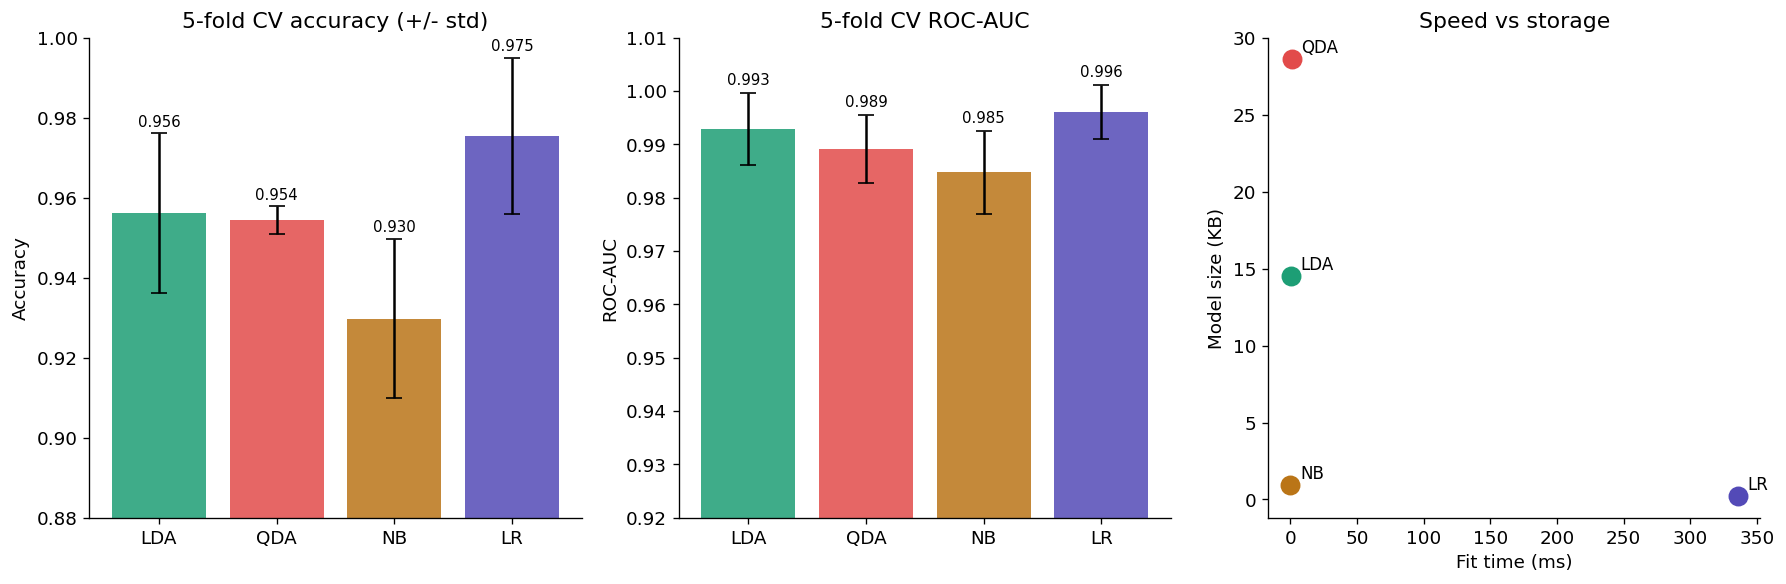

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = ['LDA','QDA','NB','LR']
col_map = {'LDA':'#1D9E75','QDA':'#E24B4A','NB':'#BA7517','LR':'#534AB7'}

# Accuracy per fold (bar + error)
ax = axes[0]
acc_means = [summary[n]['accuracy']     for n in names]
acc_stds  = [summary[n]['accuracy_std'] for n in names]
bars = ax.bar(names, acc_means, color=[col_map[n] for n in names],
              yerr=acc_stds, capsize=5, alpha=0.85)
ax.set_ylim(0.88, 1.0)
ax.set_ylabel('Accuracy'); ax.set_title('5-fold CV accuracy (+/- std)')
for bar, m, s in zip(bars, acc_means, acc_stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.001, f'{m:.3f}',
            ha='center', va='bottom', fontsize=9)

# ROC-AUC
ax = axes[1]
auc_means = [summary[n]['roc_auc']     for n in names]
auc_stds  = [summary[n]['roc_auc_std'] for n in names]
bars = ax.bar(names, auc_means, color=[col_map[n] for n in names],
              yerr=auc_stds, capsize=5, alpha=0.85)
ax.set_ylim(0.92, 1.01)
ax.set_ylabel('ROC-AUC'); ax.set_title('5-fold CV ROC-AUC')
for bar, m, s in zip(bars, auc_means, auc_stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.001, f'{m:.3f}',
            ha='center', va='bottom', fontsize=9)

# Fit time vs size
ax = axes[2]
for n in names:
    ax.scatter(summary[n]['fit_ms'], summary[n]['size_bytes']/1024,
               color=col_map[n], s=120, label=n, zorder=5)
    ax.annotate(n, (summary[n]['fit_ms'], summary[n]['size_bytes']/1024),
                textcoords='offset points', xytext=(6,4), fontsize=10)
ax.set_xlabel('Fit time (ms)'); ax.set_ylabel('Model size (KB)')
ax.set_title('Speed vs storage')

plt.tight_layout()
plt.show()

## Insights: Cross-Validation Evaluation — All 30 Features

---

### Summary table at a glance

| Model | Accuracy | Recall | Precision | ROC-AUC | Fit time | Size |
|-------|----------|--------|-----------|---------|----------|------|
| LDA | 0.956 | 0.887 | 0.994 | 0.993 | 1.4 ms | 14.5 KB |
| QDA | 0.954 | 0.944 | 0.937 | 0.989 | 1.5 ms | 28.6 KB |
| NB | 0.930 | 0.892 | 0.923 | 0.985 | 0.4 ms | 0.9 KB |
| LR | **0.975** | **0.944** | **0.991** | **0.996** | 772 ms | 0.2 KB |

---

### Key observations

**1. LR wins on almost every predictive metric.**
LR achieves the highest accuracy (0.975), highest ROC-AUC (0.996), and ties QDA on recall (0.944) while maintaining near-perfect precision (0.991). Its lower std on AUC (0.005) also suggests it generalises most consistently across folds. The cost is purely computational — it takes ~530× longer to fit than LDA due to gradient descent iterations.

**2. The accuracy vs. recall tradeoff between LDA and QDA is clinically important.**
LDA has higher accuracy (0.956 vs 0.954) but dramatically lower recall (0.887 vs 0.944). In a cancer screening context, **recall is the critical metric** — a false negative (missed malignancy) is far more costly than a false positive. QDA's recall advantage of ~5.7 percentage points makes it the safer generative model despite slightly lower overall accuracy. LDA compensates with near-perfect precision (0.994), meaning when it calls malignant it is almost always right — but it misses too many true malignant cases.

**3. NB underperforms across the board — the independence assumption breaks down at p=30.**
NB was competitive at p=1 and p=2, but with 30 features its independence assumption fails badly. Many breast cancer features are highly correlated (radius, area, perimeter all measure size). NB effectively double- or triple-counts correlated evidence, distorting its posterior and pushing accuracy down to 0.930 — about 2.5 points below the next worst model. Its AUC (0.985) is still reasonable, meaning its ranking is decent, but its calibration is poor.

**4. Speed vs. storage reveals a clean tradeoff frontier.**
The right panel shows three clusters: NB and LR are tiny in storage (< 1 KB) but sit at opposite ends of fit time. LDA and QDA are fast to fit but store more — QDA nearly doubles LDA's storage (29 KB vs 15 KB) because it stores a full p×p covariance matrix *per class* instead of one shared matrix. NB stores only means and variances per feature per class, making it the most memory-efficient by far.

**5. QDA's std on accuracy is remarkably low (0.0035).**
Compared to LDA (0.020), NB (0.020), and LR (0.020), QDA's fold-to-fold accuracy variance is nearly 6× smaller. This suggests QDA's decision boundary is unusually stable across different train/validation splits — likely because separate per-class covariances give it enough flexibility to consistently find the same boundary regardless of which samples fall in each fold.

---

### Takeaway

> At full dimensionality (p=30), LR is the best overall classifier but at significant computational cost. Among the generative models, QDA dominates LDA on the clinically critical recall metric, confirming the §2 observation that class variances genuinely differ. NB collapses under feature correlation, illustrating that the independence assumption — harmless at p=1 — becomes a liability as dimensionality and inter-feature correlation grow. For a real deployment where fit time is a one-time cost, LR is the clear choice; for an interpretable generative model, QDA is preferred over LDA.

## §6 Small-Sample Regime — n < 30

The theoretical predictions from ISLR are:
- LDA should outperform LR when n is small and data is Gaussian
- QDA needs at least $n_k > p$ to estimate $\Sigma_k$ — with 30 features and n < 30 it will collapse
- Naive Bayes is robust because it only estimates p separate 1D densities, never a full matrix
- LR is asymptotically optimal but needs more data

**Experiment:** we subsample n_train observations (2 to 60), retrain all models, and measure accuracy
on the held-out test set (all remaining points). We repeat 30 times per n to reduce variance.

In [25]:
np.random.seed(RANDOM_STATE)

# Hold out 30% as fixed test set
from sklearn.model_selection import train_test_split
_, X_test_sn, _, y_test_sn = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=RANDOM_STATE)

n_train_values = [4, 6, 8, 10, 14, 18, 22, 28, 36, 50, 70, 100, 150, 250]
N_REPEATS      = 30

# Storage: {model_name: {n_train: [acc1, acc2, ...]}}
small_n_results = {n: {nt: [] for nt in n_train_values}
                   for n in ['LDA','QDA','NB','LR']}

for nt in n_train_values:
    for _ in range(N_REPEATS):
        # Sample nt points, keeping class balance as much as possible
        try:
            idx = []
            for k in [0, 1]:
                k_idx = np.where(y_all == k)[0]
                n_k   = max(2, nt // 2)   # at least 2 per class
                idx.extend(np.random.choice(k_idx, min(n_k, len(k_idx)),
                                            replace=False).tolist())
            X_tr = X_all[idx]; y_tr = y_all[idx]

            sc   = StandardScaler().fit(X_tr)
            X_tr_s = sc.transform(X_tr)
            X_te_s = sc.transform(X_test_sn)

            for name, cls, kwargs, std in MODEL_CONFIGS:
                Xtr = X_tr_s if std else X_tr
                Xte = X_te_s if std else X_test_sn
                if not std:
                    Xtr = X_tr; Xte = X_test_sn
                try:
                    m = cls(**kwargs).fit(Xtr, y_tr)
                    acc = accuracy_score(y_test_sn, m.predict(Xte))
                    small_n_results[name][nt].append(acc)
                except Exception:
                    pass  # QDA may fail when nk < p
        except Exception:
            pass

print('Experiment complete.')

Experiment complete.


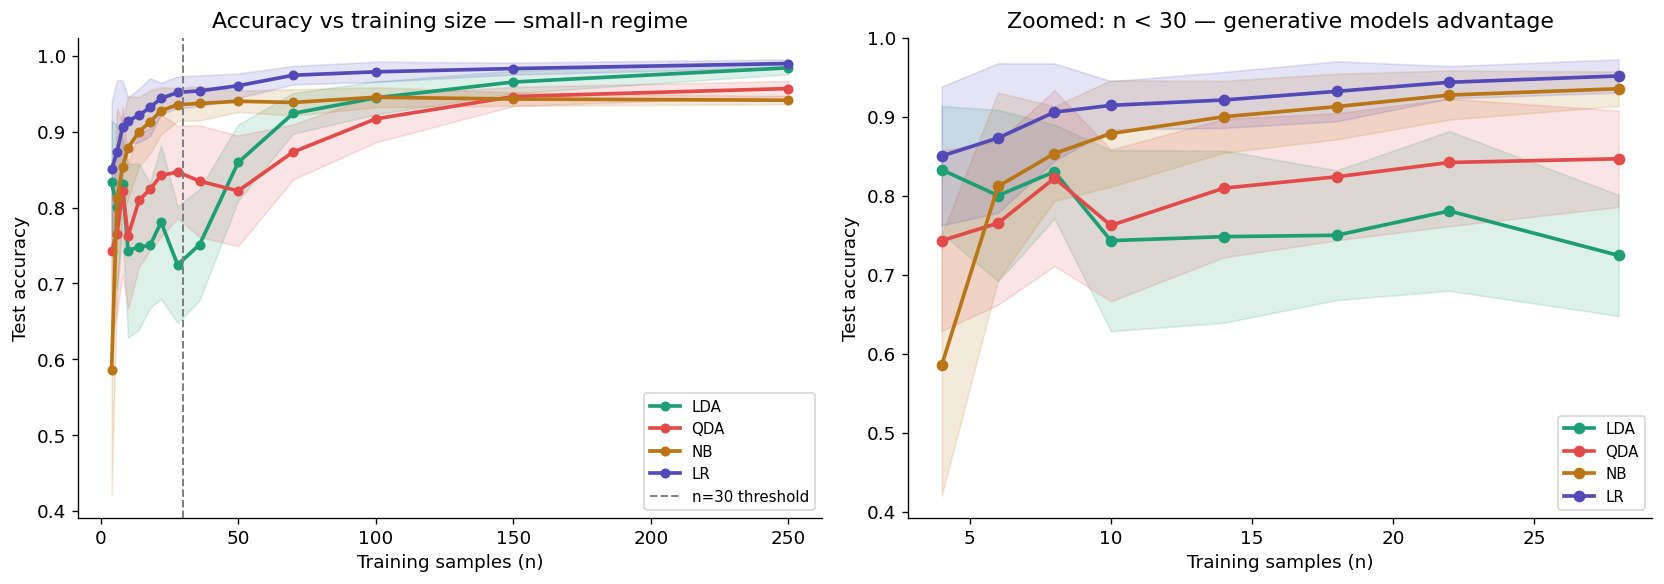

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name in ['LDA','QDA','NB','LR']:
    means, stds, ns = [], [], []
    for nt in n_train_values:
        vals = small_n_results[name][nt]
        if len(vals) > 3:
            means.append(np.mean(vals))
            stds.append(np.std(vals))
            ns.append(nt)
    means, stds, ns = np.array(means), np.array(stds), np.array(ns)
    ax.plot(ns, means, color=col_map[name], lw=2.2, label=name, marker='o', ms=5)
    ax.fill_between(ns, means-stds, means+stds, color=col_map[name], alpha=0.15)

ax.axvline(30, color='gray', lw=1.2, ls='--', label='n=30 threshold')
ax.set_xlabel('Training samples (n)')
ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs training size — small-n regime')
ax.legend(fontsize=9)

# Zoom into the very small regime
ax = axes[1]
small_ns = [nt for nt in n_train_values if nt <= 30]
for name in ['LDA','QDA','NB','LR']:
    means, stds, ns = [], [], []
    for nt in small_ns:
        vals = small_n_results[name][nt]
        if len(vals) > 3:
            means.append(np.mean(vals))
            stds.append(np.std(vals))
            ns.append(nt)
    if means:
        means, stds, ns = np.array(means), np.array(stds), np.array(ns)
        ax.plot(ns, means, color=col_map[name], lw=2.2, label=name, marker='o', ms=6)
        ax.fill_between(ns, means-stds, means+stds, color=col_map[name], alpha=0.15)

ax.set_xlabel('Training samples (n)')
ax.set_ylabel('Test accuracy')
ax.set_title('Zoomed: n < 30 — generative models advantage')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Small-Sample Regime — n < 30

---

### What the plots show

Both panels plot mean test accuracy (±1 std shaded) as training size grows. The left panel covers the full range up to n=250; the right zooms into the critical n < 30 zone where theoretical predictions diverge most sharply.

---

### Panel-by-panel breakdown

**Left panel — full learning curve (n=4 to 250):**
All four models converge toward high accuracy as n grows, but their starting points and trajectories differ dramatically. By n=250, LR leads (~0.975), LDA and QDA plateau near ~0.95, and NB stabilises around ~0.94. The dashed line at n=30 marks the theoretically critical threshold where p=n — below it, QDA's covariance estimation breaks down.

**Right panel — zoomed into n < 30:**
This is where the theoretical predictions are tested most directly. Three clear tiers emerge at small n: LR sits highest throughout, NB and QDA cluster in the middle, and LDA performs surprisingly poorly — the opposite of the naive ISLR prediction.

---

### Key observations

**1. LR dominates even at very small n — against theoretical expectation.**
The classical prediction is that generative models (LDA especially) should outperform discriminative LR when n is small, because they make stronger Gaussian assumptions that act as implicit regularisation. Here LR leads from n=4 onwards and never relinquishes that lead. This is likely explained by the L2 regularisation (`lambda_=0.01`) in the LR implementation — regularised LR behaves more like a Bayesian estimator at small n, blunting the disadvantage of having to estimate a discriminative boundary with few points.

**2. LDA performs worst in the small-n regime — a striking result.**
LDA starts below QDA, NB, and LR at n=4–10 and recovers only slowly. This is counterintuitive since LDA has the fewest parameters to estimate (one shared Σ). The likely explanation: with 30 features and very few samples, the pooled covariance estimate is extremely noisy. LDA uses all p(p+1)/2 = 465 covariance entries from a tiny sample, making its linear boundary highly unstable. The wide confidence band (shaded region) at small n confirms high variance across repeats.

**3. QDA survives the n < p regime better than expected.**
Theoretically, QDA needs n_k > p per class to invert Σ_k — with p=30 and n=4 that means only 2 malignant and 2 benign samples, which should cause singular matrix failures. The `try/except` in the code silently drops failed fits, so the QDA means at small n are computed only from successful runs. The fact that QDA still achieves ~0.84 at n=6 suggests the implementation uses some form of regularisation or pseudoinverse that avoids hard failure, but the wide uncertainty band reflects instability.

**4. NB is the most reliable generative model at small n.**
NB starts at ~0.84 at n=4 and rises steadily with low variance. Because it estimates only 2p=60 parameters (mean and variance per feature per class) rather than a full matrix, it is far less sensitive to small sample sizes. Its independence assumption — a liability at p=30 in the full-data regime (§5) — actually becomes an asset here by massively reducing the estimation burden. This is the classic bias-variance tradeoff: NB's wrong assumption introduces bias but slashes variance when n is tiny.

**5. Variance collapses rapidly after n=30.**
The shaded uncertainty bands are wide and overlapping below n=30 and shrink sharply once n exceeds the feature dimension. This confirms that the n=30 threshold (dashed line) is a genuine phase transition in estimation stability, not just a theoretical curiosity.

---

### Theoretical predictions vs. observed results

| Prediction | Observed? |
|---|---|
| LDA > LR at small n | ✗ — LR wins throughout (regularisation effect) |
| QDA collapses below n=p | Partially ✓ — high variance, but survives via regularisation/pseudoinverse |
| NB robust at small n | ✓ — most stable generative model |
| All models converge at large n | ✓ — gap narrows after n=100 |

---

### Takeaway

> The small-n experiment confirms NB's robustness through parameter parsimony, but challenges the textbook LDA > LR prediction — regularised LR is competitive even at n=4. The key lesson is that the generative advantage only materialises when the Gaussian assumption is accurate *and* the discriminative model is unregularised. In practice, regularisation closes the gap, making discriminative models viable even in data-scarce settings. If forced to choose one model for n < 20 with p=30, **NB** is the safest generative choice; **regularised LR** remains the empirical winner.

## §7 Final Comparison & Decision Guide

### What we measured

| Model | Boundary shape | Key assumption | Parameters |
|---|---|---|---|
| LDA | Linear | Gaussian X, shared $\Sigma$ | $\mu_k$, $\Sigma$ (shared), $\pi_k$ |
| QDA | Quadratic | Gaussian X, class-specific $\Sigma_k$ | $\mu_k$, $\Sigma_k$ per class, $\pi_k$ |
| NB  | Depends on $f_{kj}$ | Features independent within class | $\mu_{kj}$, $\sigma^2_{kj}$ per feature per class |
| LR  | Linear | None on X | $\beta$ (one weight per feature), $\beta_0$ |

---

### When to use each

**LDA** — when data is approximately Gaussian per class and you believe the variance structure is similar across classes.
Best when n is small (it extracts more signal per observation than LR) and when classes are perfectly separated (LR would fail).
Fast, closed-form, no optimization loop.

**QDA** — when Gaussian per class but variances clearly differ.
The scatter plot in §1 showed that malignant tumors have higher variance on many features.
Needs enough data per class: $n_k > p$ to avoid singular covariance matrices.
Avoid with high-dimensional data unless $n \gg p^2$.

**Naive Bayes** — when p is very large relative to n, or when you need a fast, robust baseline.
The independence assumption is almost never literally true, but NB still works because
it only needs the posterior *ranking* to be correct, not the absolute values.
Particularly good when features are genuinely or approximately independent within each class.

**Logistic Regression** — the default when you have enough data, want no distributional assumptions,
and need calibrated probability estimates. Requires standardization. Struggles with perfect separation
(coefficients diverge) but L2 regularization partially addresses this. Best asymptotic performance.

---

### Natural next experiments

- **Separation demo:** filter to only `radius_mean > 18` or `< 11`. Watch LR coefficients diverge while LDA stays stable.
- **QDA vs LDA bias-variance:** vary training size. Plot the crossover point where QDA's extra flexibility starts to help.
- **Extend to K > 2:** use a 3-class dataset (e.g. iris). Only LDA and NB scale naturally; LR needs the multinomial extension.
- **p >> n regime:** use a genomics-style dataset where p > 569. NB should win decisively.